# Предсказание прочности бетона

Цель проекта - создать модель, которая будет предсказывать прочность бетона по примесям, которые входят в его состав

В ходе выполнения проекта будут выполнены следующие шаги
1. Подготовка данных
2. Визуализация даных
3. Применение методов машинного обучения

Описание датафрейма

1. Cement — Цемент — кг в м³ смеси — входная переменная
2. Blast Furnace Slag — Шлак доменный — кг в м³ смеси — входная переменная
3. Fly Ash — Зола-унос — кг в м³ смеси — входная переменная
4. Water — Вода — кг в м³ смеси — входная переменная
5. Superplasticizer — Суперпластификатор — кг в м³ смеси — входная переменная
6. Coarse Aggregate — Крупный заполнитель — кг в м³ смеси — входная переменная
7. Fine Aggregate — Мелкий заполнитель — кг в м³ смеси — входная переменная
8. Age — Возраст — дни (от 1 до 365) — входная переменная
9. Concrete compressive strength — Прочность бетона на сжатие — мегапаскали (МПа) — целевая переменная

## Подготовка данных

Импортирует модуля warnings для работы с предупреждениями.

In [171]:
import warnings
warnings.simplefilter(action = 'ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
def ignore_warn(*args, **kwargs):
    pass
warnings.warn = ignore_warn 

импорт библиотек

In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno

from phik.report import plot_correlation_matrix

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer

считывание и сохранение датафрейма

In [173]:
data = pd.read_excel('Concrete_Data.xls')

Рассмотрим датафрейм поподробнее

In [174]:
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [175]:
data.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


рассмотрим датафрейм на пропуски

In [176]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

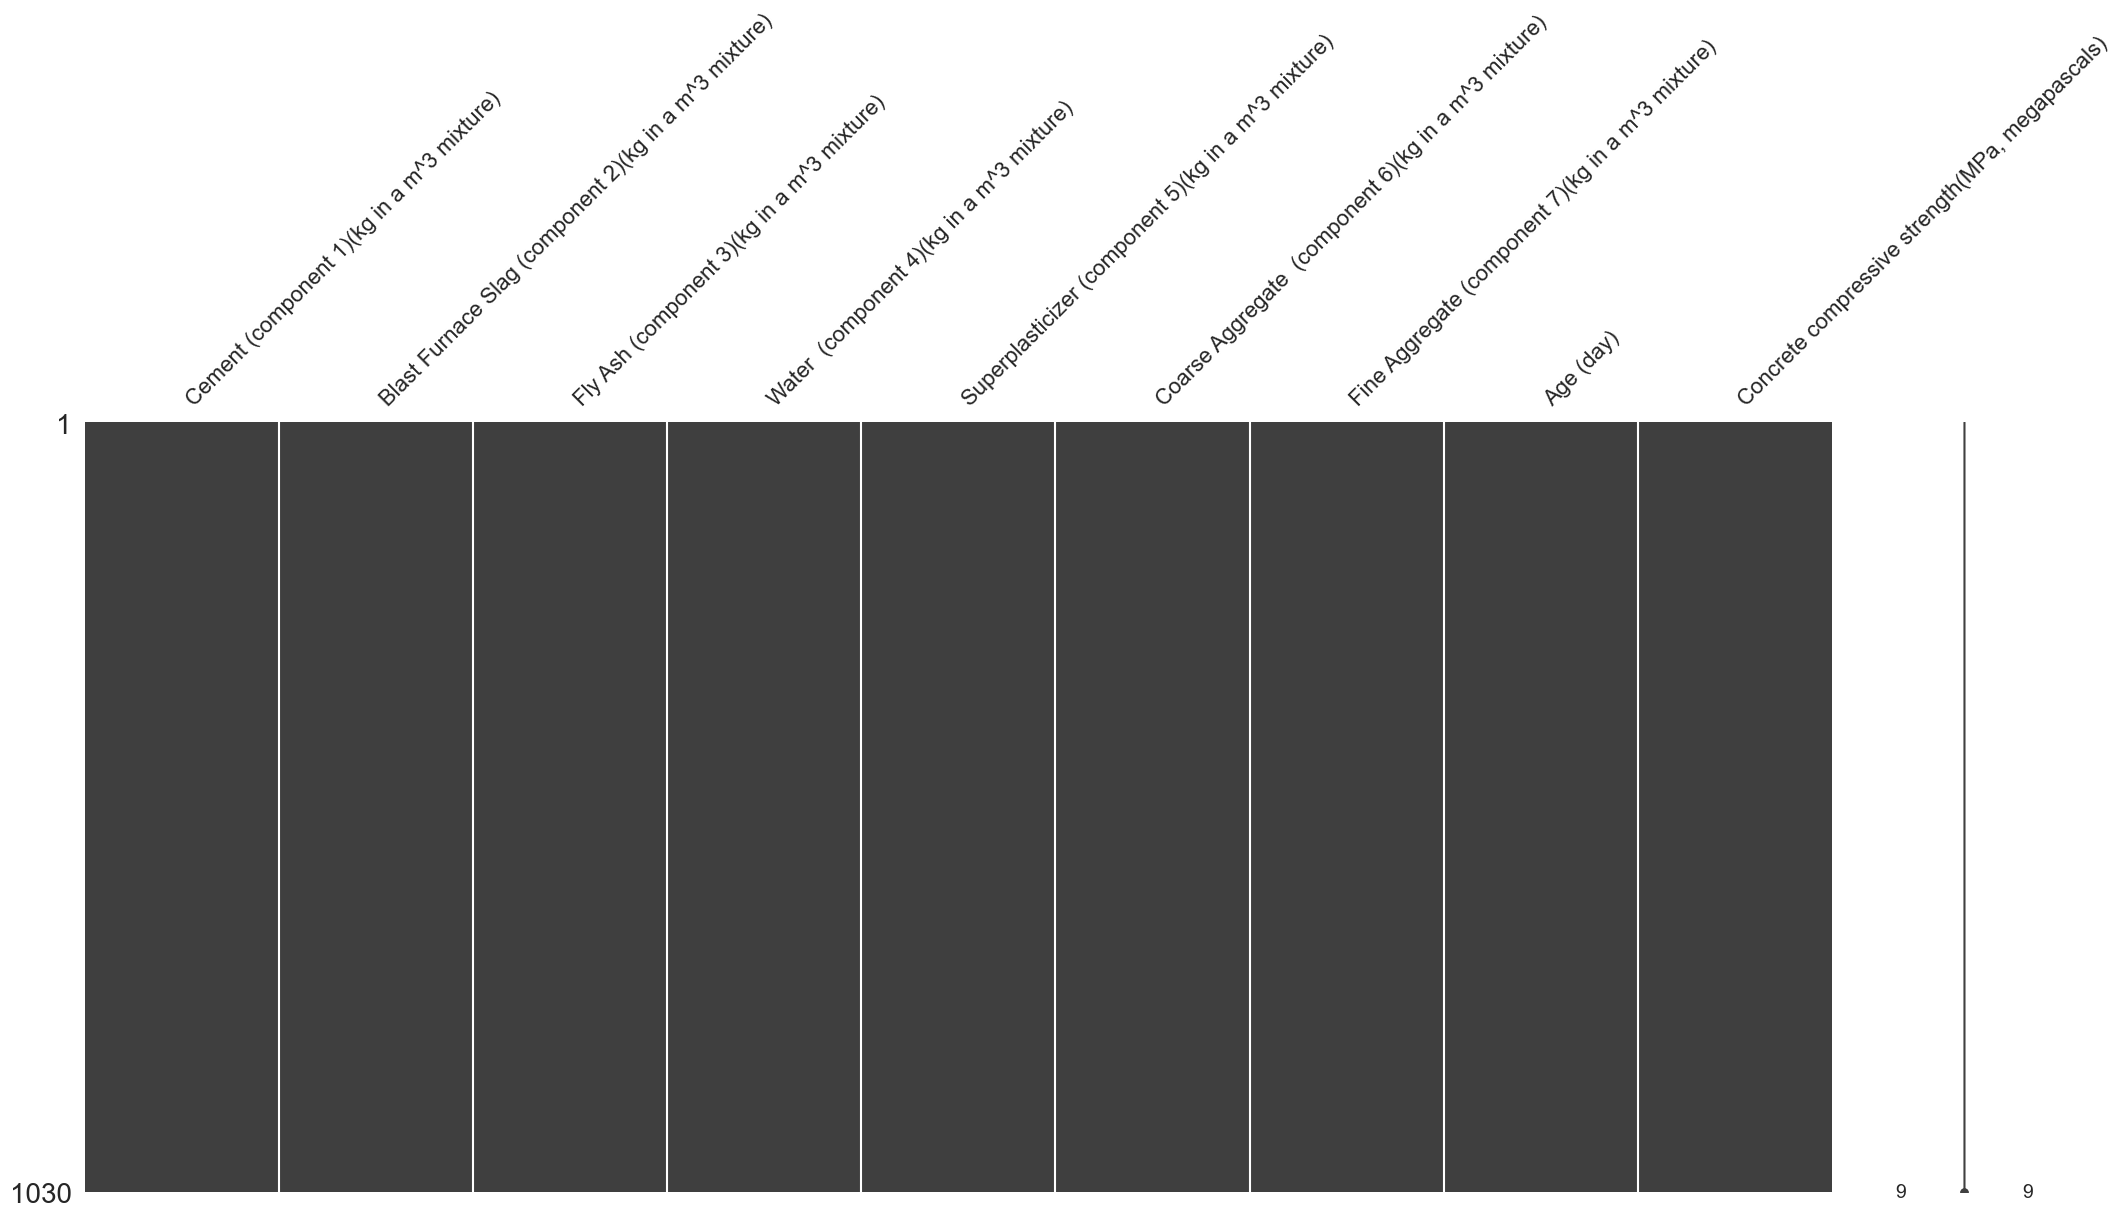

In [177]:
msno.matrix(data);

пропусков нет

посмотрим, корректно ли записаны названия столбцов и переименуем их, если формат не подходит

In [178]:
print(data.columns)

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')


In [179]:
data = data.rename(columns={'Concrete compressive strength(MPa, megapascals) ': 'Concrete compressive strength(MPa, megapascals)',
                            'Water  (component 4)(kg in a m^3 mixture)' : 'Water (component 4)(kg in a m^3 mixture)',
                            'Coarse Aggregate  (component 6)(kg in a m^3 mixture)': 'Coarse Aggregate (component 6)(kg in a m^3 mixture)'})

сохраним названия для дальнейшей визуализации данных

In [180]:
cols = data.columns.tolist()
print(cols)

['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals)']


проверим на наличие дубликатов, которые могут препятствовать дальнейшему машинному обучению

In [181]:
print(f'Количество дубликатов {data.duplicated().sum()}')

Количество дубликатов 25


Удалим их

In [182]:
data = data.drop_duplicates()
print(f'Количество дубликатов {data.duplicated().sum()}')

Количество дубликатов 0


## Визуализация данных

С помощью гистограмм рассмотрим распределение данных. Также рассмотрим на этих графиках средние значения

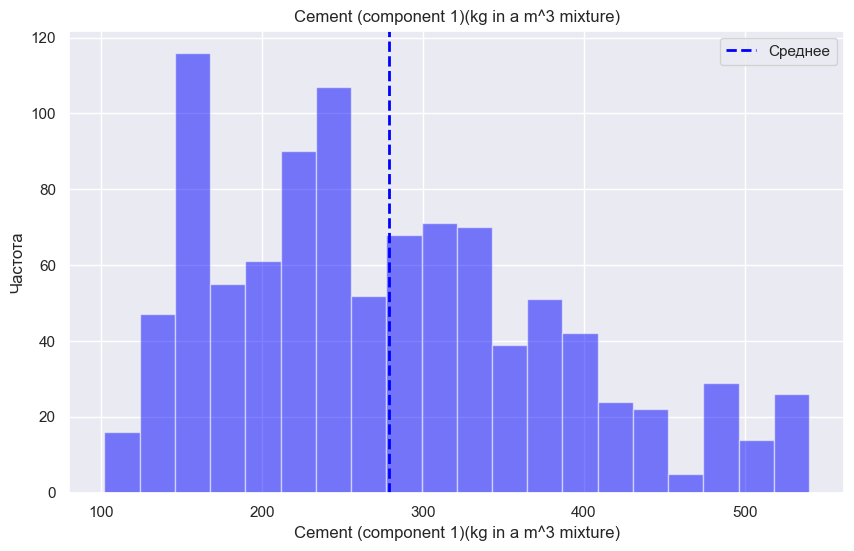

Среднее значение для "Cement (component 1)(kg in a m^3 mixture)": 278.63
--------------------------------------------------


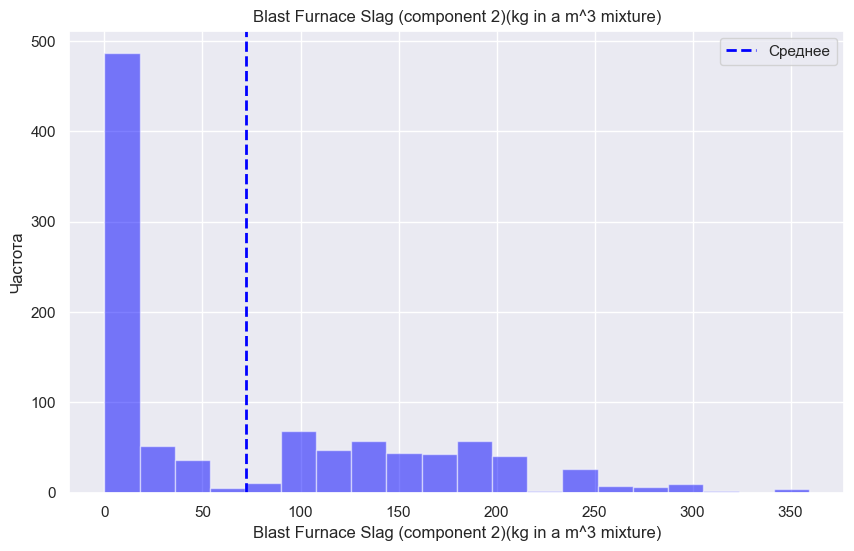

Среднее значение для "Blast Furnace Slag (component 2)(kg in a m^3 mixture)": 72.04
--------------------------------------------------


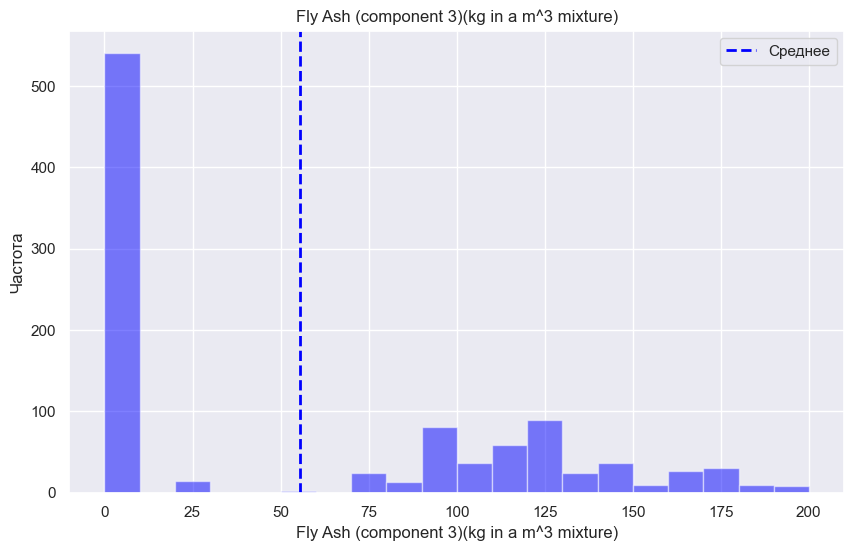

Среднее значение для "Fly Ash (component 3)(kg in a m^3 mixture)": 55.54
--------------------------------------------------


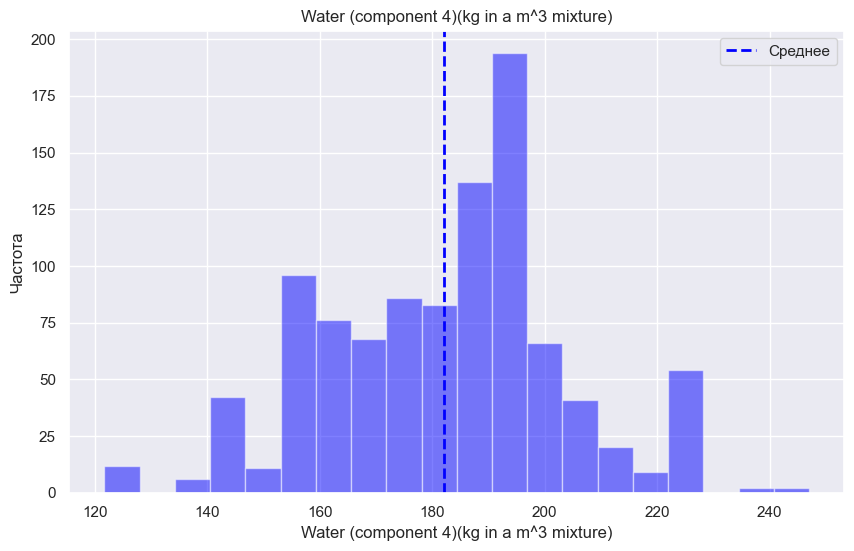

Среднее значение для "Water (component 4)(kg in a m^3 mixture)": 182.07
--------------------------------------------------


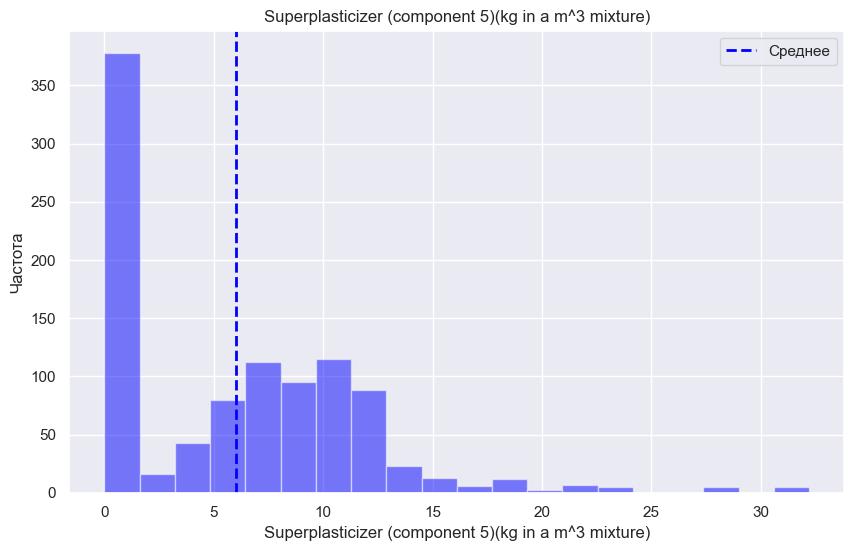

Среднее значение для "Superplasticizer (component 5)(kg in a m^3 mixture)": 6.03
--------------------------------------------------


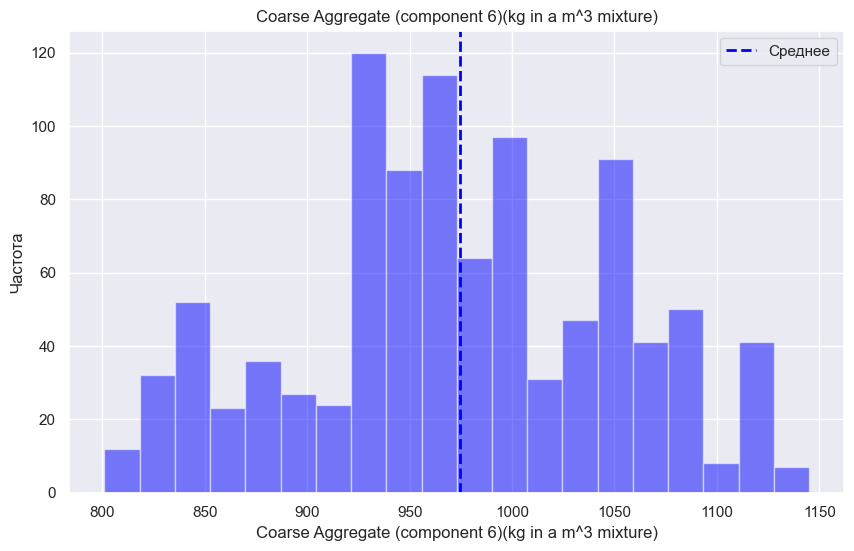

Среднее значение для "Coarse Aggregate (component 6)(kg in a m^3 mixture)": 974.38
--------------------------------------------------


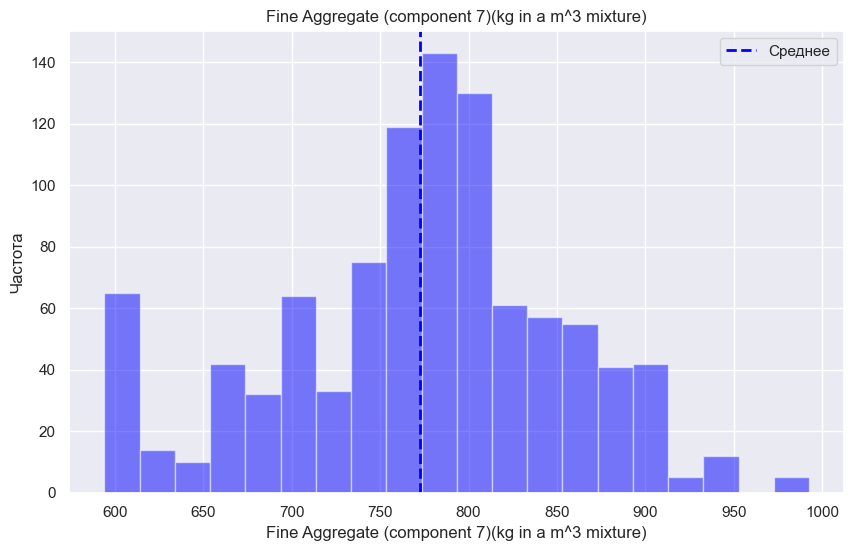

Среднее значение для "Fine Aggregate (component 7)(kg in a m^3 mixture)": 772.69
--------------------------------------------------


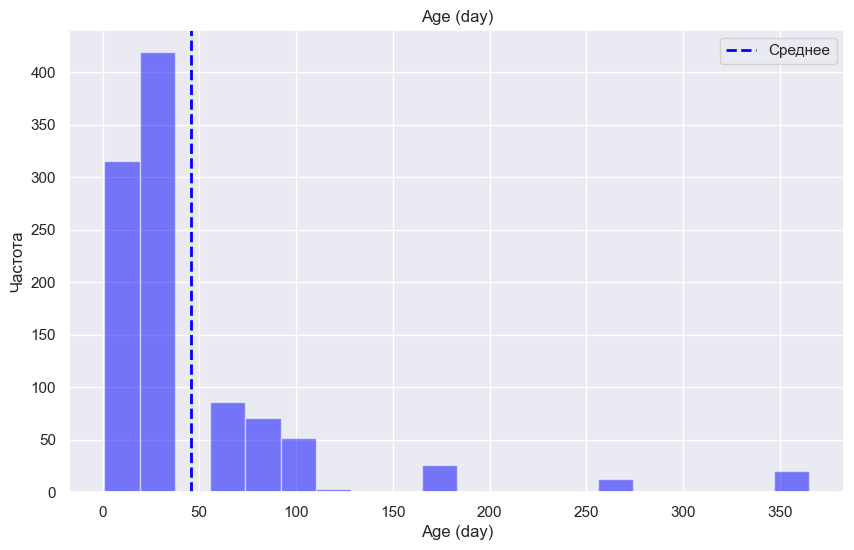

Среднее значение для "Age (day)": 45.86
--------------------------------------------------


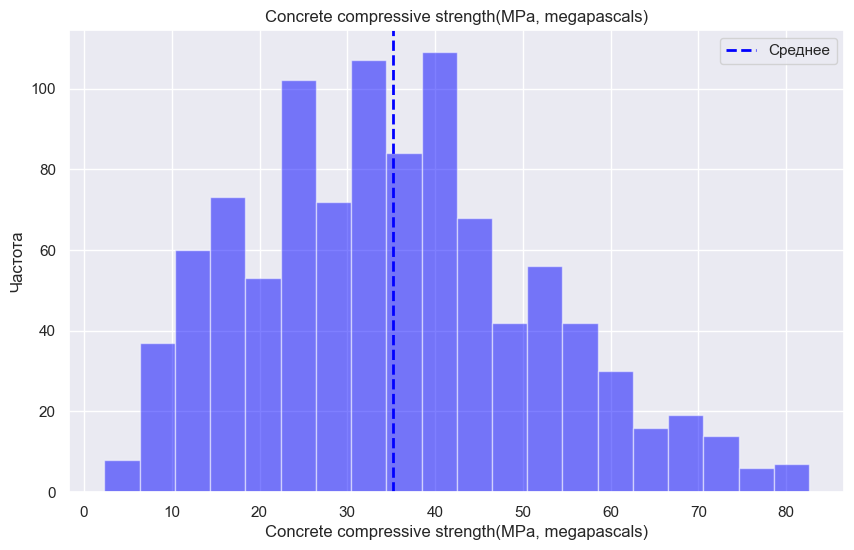

Среднее значение для "Concrete compressive strength(MPa, megapascals)": 35.25
--------------------------------------------------


In [183]:
for col in cols:
    plt.figure(figsize=(10, 6))  
    plt.hist(data[col], bins=20, alpha=0.5, color='blue')
    mean = data[col].mean()
    plt.axvline(mean, color='blue', linestyle='dashed', linewidth=2, label='Среднее')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.legend()
    plt.show()
    print(f'Среднее значение для "{col}": {mean:.2f}')
    print('-' * 50)

С помощью столбчатых диаграмм размаха рассмотрим данные на наличие аномалий

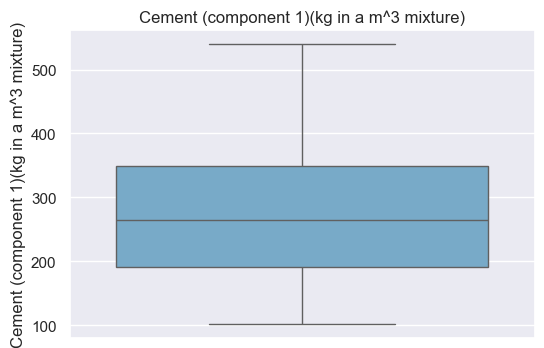

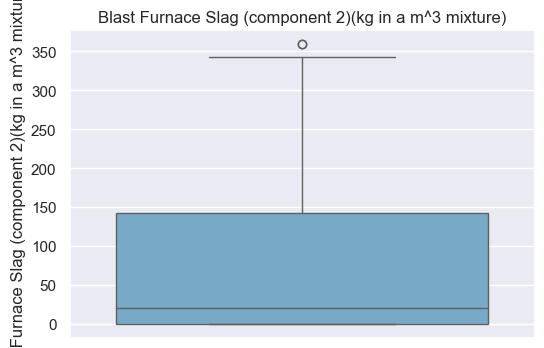

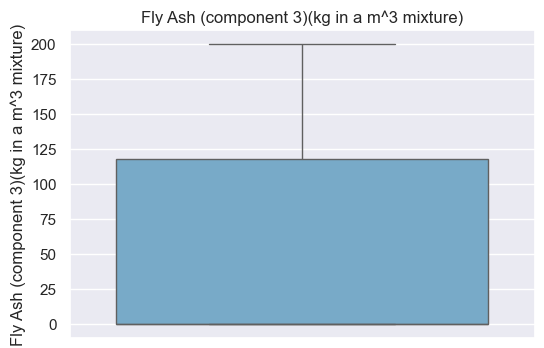

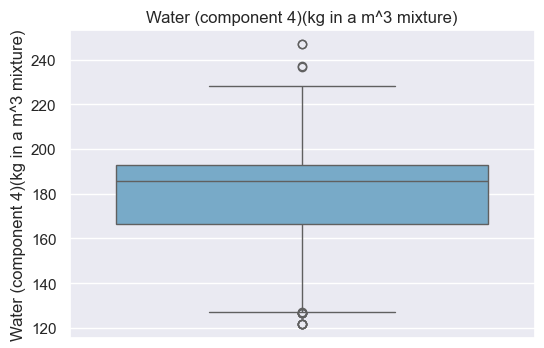

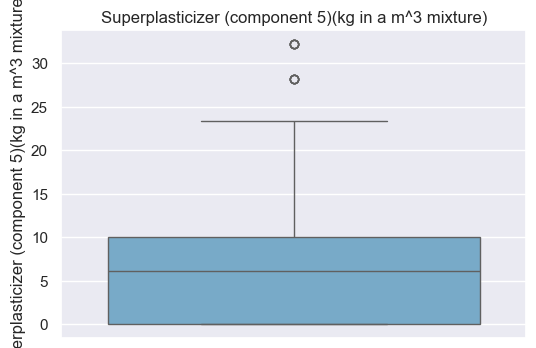

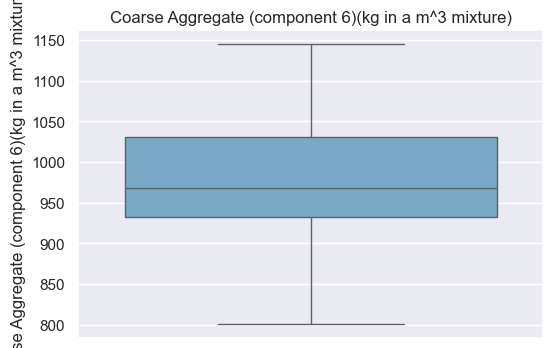

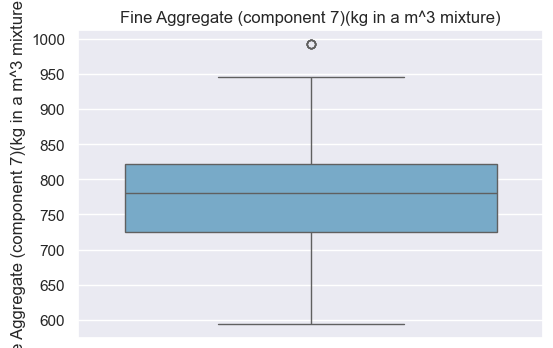

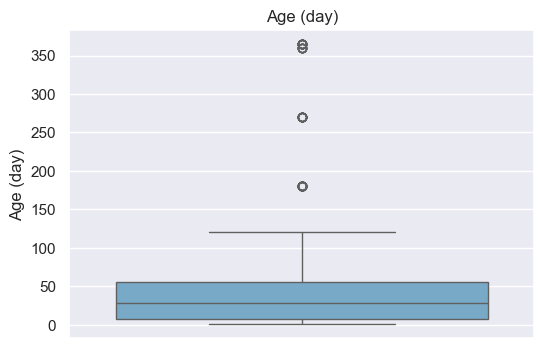

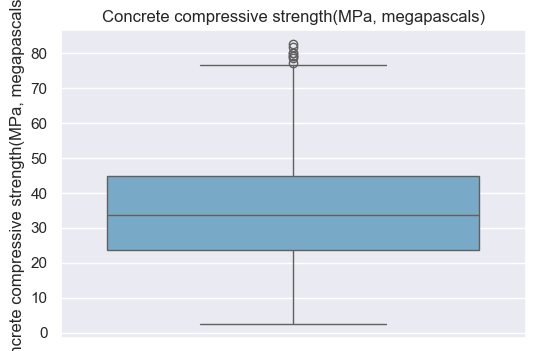

In [184]:
for col in cols:
    sns.set()
    plt.figure(figsize=(6, 4))
    plt.title(col)
    sns.boxplot(data=data[col],palette="Blues")  
    plt.show()

Несмотря на то, что параметр Age (day) имеет выбросы, они находятся в допустимых пределах (если подумать логически), поэтому не будем применять нормализацию (также это не влияет в дальнейшем на качество модели)

Теперь построим матрицу корреляции, чтобы рассмотреть зависимость меджду входным и целевым признаками. Также рассмотрим датафрейм на мультиколлинеарность.

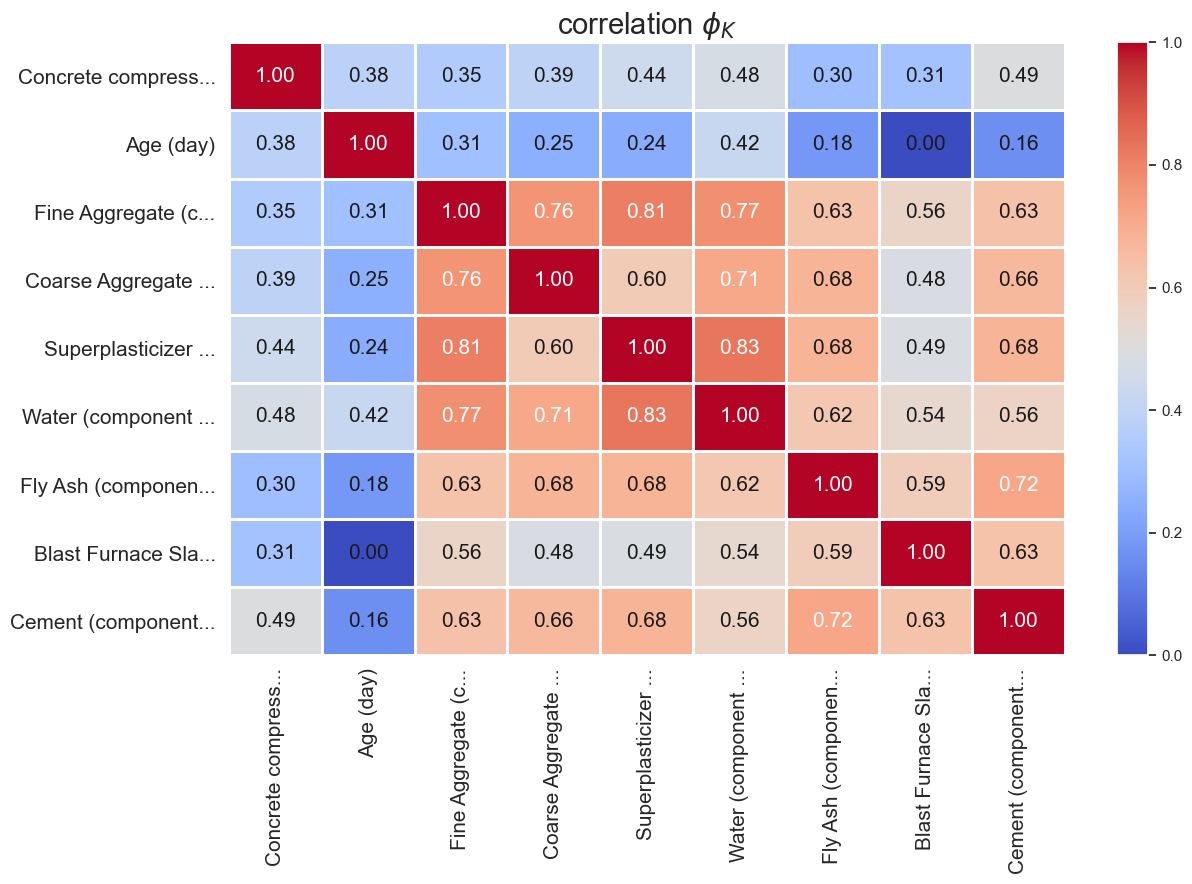

In [185]:
phik_overview = data.phik_matrix(interval_cols = cols)
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(13, 9)
);

Будем считать6 что мультиколлинеарность имеется при коллинеарности <=0.9 между входными признаками, поэтому, в нашем случае её нет. Тем не менее, удалим признак Fly Ash (component 3)(kg in a m^3 mixture). Он слабо коррелирует с целевым и сильно со многими входными (это улучшило качество модели) 

Также с помощью скаттерплотов визуализируем зависимости между входными признаками и целевым

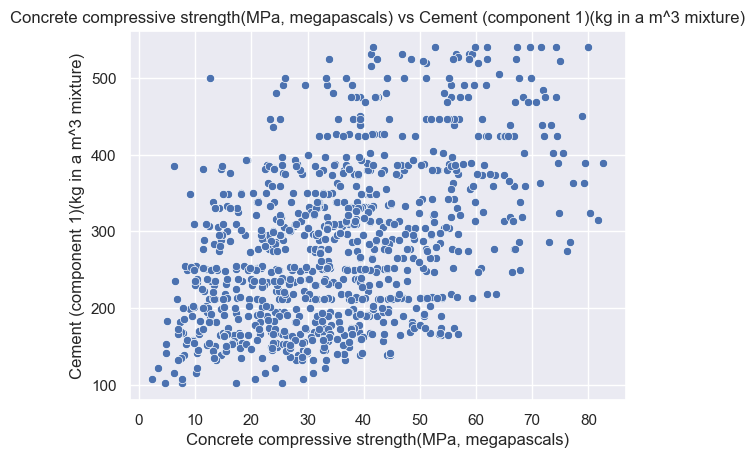

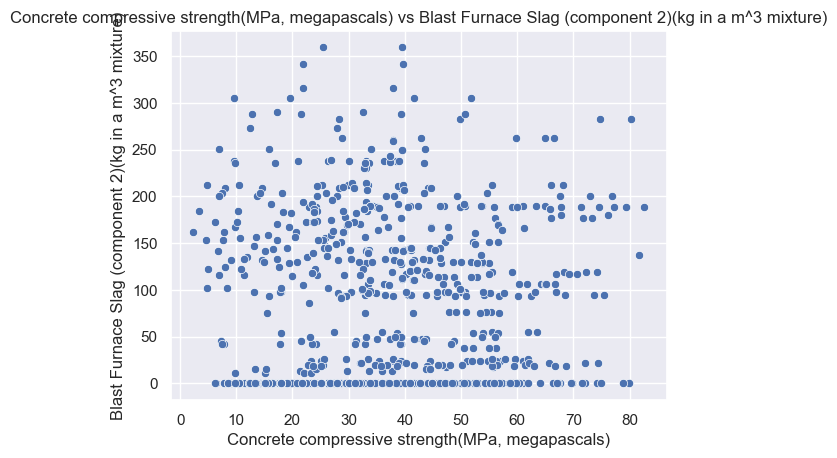

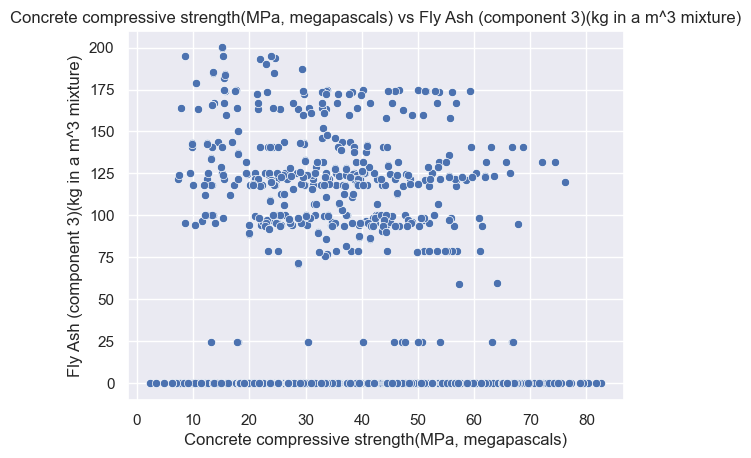

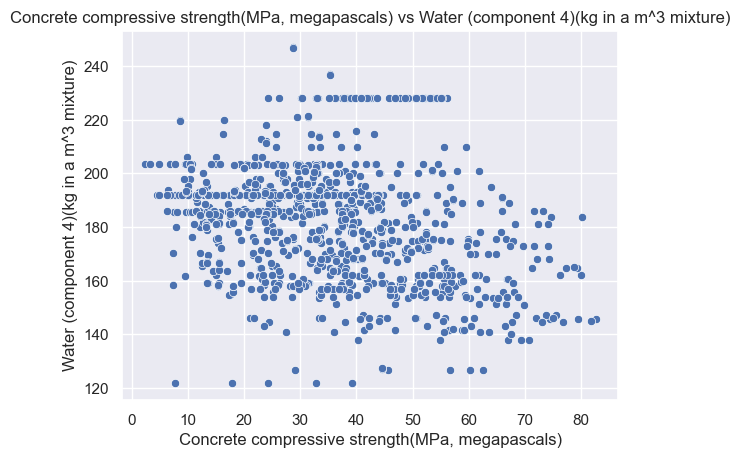

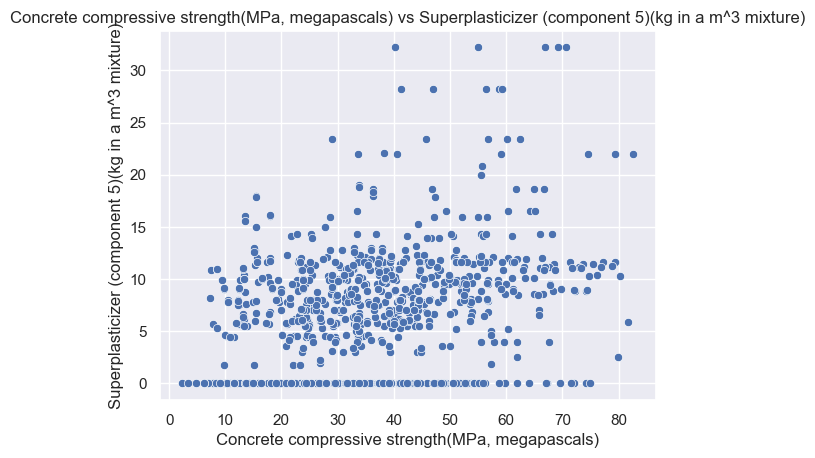

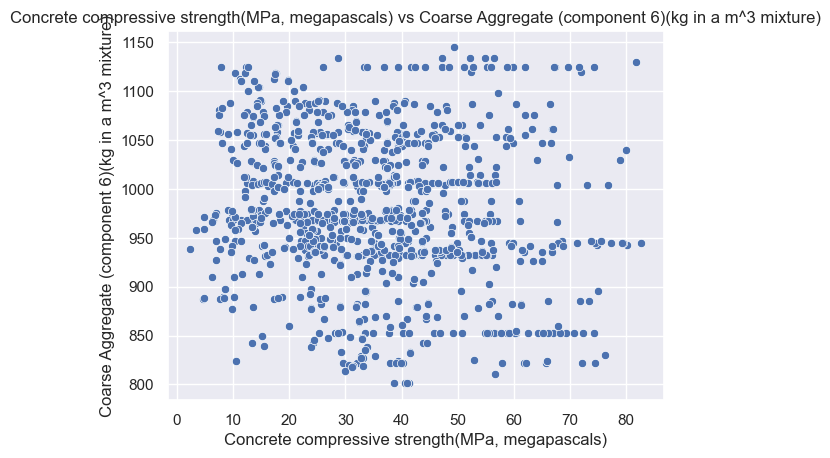

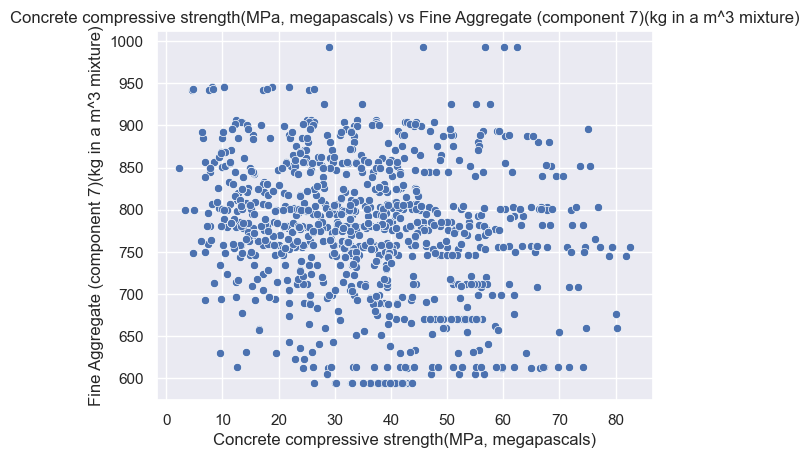

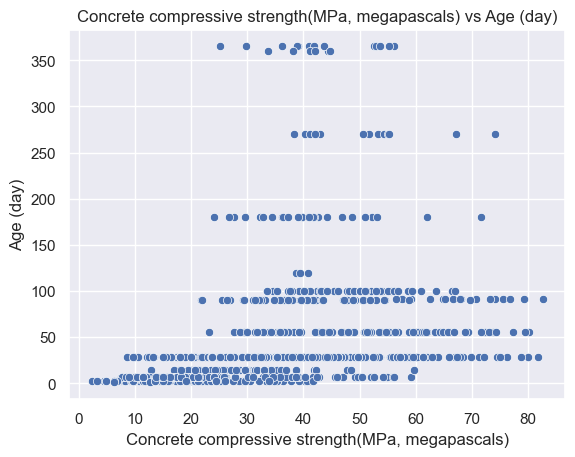

In [186]:
cols.remove('Concrete compressive strength(MPa, megapascals)')
for column in cols:
    sns.scatterplot(data=data, x='Concrete compressive strength(MPa, megapascals)', y=column)
    plt.title(f"Concrete compressive strength(MPa, megapascals) vs {column}")
    plt.xlabel('Concrete compressive strength(MPa, megapascals)')
    plt.show()

Входные признаки преимущественно имеют нелинейную зависимость с целевым, поэтому в дальнешем применим полиномизацию

видно, что признву Age (day) можно разделить на несколько классов (это улучшило в двльнейшем качество модели)

In [187]:
bins = [0, 50, 150, 200, 300, 366]  # Границы интервалов
labels = ['0', '1', '2', '3', '4']  # Названия классов
data['Age_class'] = pd.cut(data['Age (day)'], bins=bins, labels=labels, right=False)

применим логорифмизацию к Water (component 4)(kg in a m^3 mixture)

In [188]:
data['Water (component 4)(kg in a m^3 mixture)'] = np.log1p(data['Water (component 4)(kg in a m^3 mixture)'] - data['Water (component 4)(kg in a m^3 mixture)'].min())

## Применение методов машинного обучения

Данный проект я выполняю как обучение с учителем. Из нескольких моделей (линейная регрессия, дерево решений, SVR, Ridge, Lasso) будет выбрана наилучшая с соответствующими гиперпараметрами

In [189]:
# Разделяем датафрейм на входные и целевой признак
X = data.drop(columns = ['Concrete compressive strength(MPa, megapascals)', 'Fly Ash (component 3)(kg in a m^3 mixture)'], axis=1)
y = data['Concrete compressive strength(MPa, megapascals)']

# Разбиваем на тренировочные и тестовые выбори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

poly_features = [col for col in X.columns if col != 'Age_class']  # Исключаем Age_class

# Пайплайн для полиномиальных преобразований и стандартизации
poly_pipeline_2 = Pipeline([
    ('poly2', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler2', StandardScaler())
])

poly_pipeline_3 = Pipeline([
    ('poly3', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler3', StandardScaler())
])

# Объединение результатов двух пайплайнов
combined_features = FeatureUnion([
    ('poly2_features', poly_pipeline_2),
    ('poly3_features', poly_pipeline_3)
])

# Предобработка данных
preprocessor = ColumnTransformer(
    transformers=[
        ('polys', combined_features, poly_features),  # Применяем полиномиальные преобразования к выбранным столбцам
        ('pass', 'passthrough', ['Age_class'])  # Пропускаем Age_class без изменений
    ]
)

# Параметры для RandomizedSearchCV
param_grid = [
    {'regressor': [DecisionTreeRegressor(random_state=42)],
     'regressor__max_depth': range(2, 15),
     'regressor__min_samples_split': range(2, 15)},
    {'regressor': [SVR()],
     'regressor__C': [0.1, 1, 10],
     'regressor__kernel': ['linear', 'rbf']},
    {'regressor': [Ridge(random_state=42), Lasso(random_state=42)],
     'regressor__alpha': [0.1, 1, 10, 100, 200]},
    {'regressor': [LinearRegression()]}
]

# Создание и обучение моделей
best_model = None
best_score = float('-inf')
best_params = None

for params in param_grid:
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', params['regressor'][0])])
    search = RandomizedSearchCV(pipe, params, n_iter=10, scoring='r2', cv=5, random_state=42)
    search.fit(X_train, y_train)
    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_params = search.best_params_
        best_model = search.best_estimator_

print(f"Лучшая модель: {best_model}, R^2: {best_score:.2f}, Параметры: {best_params}")

# Оценка модели на тестовых данных
predictions = best_model.predict(X_test)
r2 = r2_score(y_test, predictions)
print(f'R^2 на тестовой выборке: {r2:.2f}')

Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('polys',
                                                  FeatureUnion(transformer_list=[('poly2_features',
                                                                                  Pipeline(steps=[('poly2',
                                                                                                   PolynomialFeatures(include_bias=False)),
                                                                                                  ('scaler2',
                                                                                                   StandardScaler())])),
                                                                                 ('poly3_features',
                                                                                  Pipeline(steps=[('poly3',
                                                                                                   Polynom

В данной задаче я решил использовать пайплайн для автоматизации и упрощения процесса предобработки данных и моделирования. Для выбора наилучшей модели проводится случайный поиск по сетке параметров для различных типов регрессоров: дерево решений, SVR, Ridge и Lasso регрессии, а также линейная регрессия. Оценка качества модели осуществляется с использованием коэффициента детерминации r2. В ходе выполнения проекта было определено, что лучшей моделью является Ridge с параметром alpha=0.1. Метрика r2_score, известная как коэффициент детерминации, является одной из основных метрик для оценки качества моделей регрессии. Она показывает, насколько хорошо будущие выборки будут предсказаны моделью. Значение r2_score варьируется от -∞ до 1, где более высокие значения указывают на лучшее качество модели. 